In [32]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms
from PIL import Image

from torch.utils.data import DataLoader, TensorDataset, Dataset

In [42]:
image_dir = "../dataset/image-dataset/train"

for label, class_dir in enumerate(os.listdir(image_dir)):
    print(label, class_dir)

0 Cat
1 Dog
2 Female
3 Male


In [ ]:
class ImageDataSet(Dataset):
    def __init__(self, image_dir, transform=None):
        super().__init__()

        self.image_dir = image_dir
        self.image_paths = []   # ../dataset/image-dataset/train\Cat\cat_10001.jpg
        self.labels = []        # 0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3.....
        self.class_name = {}    # {0: 'Cat', 1: 'Dog', 2: 'Female', 3: 'Male'}
        self.transform = transform

        for label, class_dir in enumerate(os.listdir(image_dir)):
            self.class_name[label] = class_dir
            class_path = os.path.join(image_dir, class_dir) # full path for class folder
            for image_name in os.listdir(class_path): 
                self.image_paths.append(os.path.join(class_path, image_name))
                self.labels.append(label)
 
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, index):
        img_path = self.image_paths[index]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[index]
        if self.transform:
            image = self.transform(image)
            
        return image, label

     


In [50]:
ImageDataSet(image_dir)

../dataset/image-dataset/train\Cat\cat_1000.jpg
../dataset/image-dataset/train\Cat\cat_10000.jpg
../dataset/image-dataset/train\Cat\cat_10001.jpg
../dataset/image-dataset/train\Cat\cat_10002.jpg
../dataset/image-dataset/train\Cat\cat_10003.jpg
../dataset/image-dataset/train\Cat\cat_10004.jpg
../dataset/image-dataset/train\Cat\cat_10005.jpg
../dataset/image-dataset/train\Cat\cat_10006.jpg
../dataset/image-dataset/train\Cat\cat_10007.jpg
../dataset/image-dataset/train\Cat\cat_10008.jpg
../dataset/image-dataset/train\Cat\cat_10009.jpg
../dataset/image-dataset/train\Cat\cat_1001.jpg
../dataset/image-dataset/train\Cat\cat_10010.jpg
../dataset/image-dataset/train\Cat\cat_10011.jpg
../dataset/image-dataset/train\Cat\cat_10012.jpg
../dataset/image-dataset/train\Cat\cat_10013.jpg
../dataset/image-dataset/train\Cat\cat_10014.jpg
../dataset/image-dataset/train\Cat\cat_10015.jpg
../dataset/image-dataset/train\Cat\cat_10016.jpg
../dataset/image-dataset/train\Cat\cat_10017.jpg
../dataset/image-datas

In [45]:
# before traing need to convert resize and convert tensor
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [46]:
transform

Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)

In [ ]:
train_image_dir = "../dataset/image-dataset/train"
test_image_dir = "../dataset/image-dataset/test"

train_image_dataset = ImageDataSet(image_dir=train_image_dir, transform=transform)
test_image_dataset = ImageDataSet(image_dir=test_image_dir, transform=transform)

../dataset/image-dataset/train\Cat\cat_1000.jpg
../dataset/image-dataset/train\Cat\cat_10000.jpg
../dataset/image-dataset/train\Cat\cat_10001.jpg
../dataset/image-dataset/train\Cat\cat_10002.jpg
../dataset/image-dataset/train\Cat\cat_10003.jpg
../dataset/image-dataset/train\Cat\cat_10004.jpg
../dataset/image-dataset/train\Cat\cat_10005.jpg
../dataset/image-dataset/train\Cat\cat_10006.jpg
../dataset/image-dataset/train\Cat\cat_10007.jpg
../dataset/image-dataset/train\Cat\cat_10008.jpg
../dataset/image-dataset/train\Cat\cat_10009.jpg
../dataset/image-dataset/train\Cat\cat_1001.jpg
../dataset/image-dataset/train\Cat\cat_10010.jpg
../dataset/image-dataset/train\Cat\cat_10011.jpg
../dataset/image-dataset/train\Cat\cat_10012.jpg
../dataset/image-dataset/train\Cat\cat_10013.jpg
../dataset/image-dataset/train\Cat\cat_10014.jpg
../dataset/image-dataset/train\Cat\cat_10015.jpg
../dataset/image-dataset/train\Cat\cat_10016.jpg
../dataset/image-dataset/train\Cat\cat_10017.jpg
../dataset/image-datas

In [52]:
len(train_image_dataset), len(test_image_dataset)

(29956, 460)

In [55]:
train_image_loader = DataLoader(dataset=train_image_dataset, batch_size=32, shuffle=True)
test_image_loader = DataLoader(dataset=test_image_dataset, batch_size=32, shuffle=True)

In [ ]:
print(train_image_dataset.class_name)
print(test_image_dataset.class_name)

In [59]:
counter = 0
for images, labels in train_image_loader:
    print(images.shape, labels.shape)
    counter += 1
    if counter == 10:
        break

torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])


In [60]:
print(train_image_dataset.class_name)
print(test_image_dataset.class_name)

{0: 'Cat', 1: 'Dog', 2: 'Female', 3: 'Male'}
{0: 'Cat', 1: 'Dog', 2: 'Female', 3: 'Male'}


image shape =====>  (3, 128, 128)
label ---> 0
Class Name Cat
(128, 128, 3)


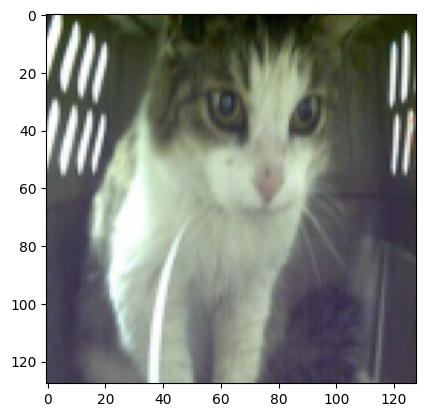

In [69]:
for images, labels in train_image_loader:
  # get first image from a batch 
  img = images[0].numpy()
  print("image shape =====> ", img.shape)
  # get first label from a batch
  label = labels[0].item()
  print("label --->", label)
  print("Class Name", train_image_dataset.class_name[label])
  img = np.transpose(img, (1,2,0))
  print(img.shape)
  plt.imshow(img, vmin=0, vmax=255)
  break